In [13]:
from diffusers import UNet2DModel, DDPMScheduler, VQModel
import torch
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from utils import im2tensor, viewimage

torch.manual_seed(6)

In [3]:
# run only once
download = False
if download:
    !wget -nc -O ffhq256-1k-validation.zip 'https://www.dropbox.com/scl/fi/pppstbdsf0em6o0qscruc/ffhq256-1k-validation.zip?rlkey=xl7nwv2nxb6yvsirr3wad77hm'
    !unzip -nq ffhq256-1k-validation.zip
    vqvae = VQModel.from_pretrained("CompVis/ldm-celebahq-256", subfolder="vqvae")
    unet = UNet2DModel.from_pretrained("CompVis/ldm-celebahq-256", subfolder="unet")
    scheduler = DDPMScheduler.from_pretrained("CompVis/ldm-celebahq-256", subfolder="scheduler")
    vqvae.save_pretrained("./models/vqvae")
    unet.save_pretrained("./models/unet")
    scheduler.save_pretrained("./models/scheduler")
    
else:
    vqvae = VQModel.from_pretrained("./models/vqvae")
    unet = UNet2DModel.from_pretrained("./models/unet")
    scheduler = DDPMScheduler.from_pretrained("./models/scheduler")

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
The config attributes {'timestep_values': None, 'timesteps': 1000} were passed to DDPMScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

unet.to(device)
vqvae.to(device)

print(device)

cpu


C:\Users\debat\AppData\Local\Temp\ipykernel_8756\2673432712.py:7: FutureWarning: Accessing config attribute `in_channels` directly via 'UNet2DModel' object attribute is deprecated. Please access 'in_channels' over 'UNet2DModel's config object instead, e.g. 'unet.config.in_channels'.
  imgshape_latent = (1, unet.in_channels, unet.sample_size, unet.sample_size)


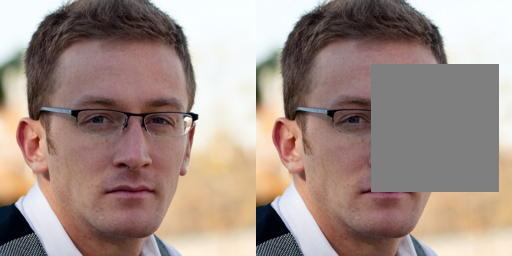

In [5]:
MODE = "inpainting"

idx = 462
x0 = im2tensor(plt.imread('ffhq256-1k-validation/'+str(idx).zfill(5)+'.png'), device=device)

imgshape = x0.shape
imgshape_latent = (1, unet.in_channels, unet.sample_size, unet.sample_size)

sigma_noise = 0.01

if MODE == "inpainting":
    h = imgshape[2]
    w = imgshape[3]
    hcrop, wcrop = h//2, w//2
    corner_top, corner_left = h//4, int(0.45*w)
    mask = torch.ones(imgshape, device=device)
    mask[:,:,corner_top:corner_top+hcrop,corner_left:corner_left+wcrop] = 0

    def linear_operator(x):
        x = x*mask
        return(x)

    x_true = x0.clone()

    y = linear_operator(x_true.clone()) + sigma_noise * mask * torch.randn_like(x_true)
    vis_y = y    
    
viewimage(torch.cat((x_true, vis_y), dim=3), titre='Ground truth and measurements', displayfilename=False)

In [6]:
scheduler.set_timesteps(num_inference_steps=100)
alphas = scheduler.alphas.to(device)
betas = scheduler.betas.to(device)
alphas_bar = scheduler.alphas_cumprod.to(device)
betas_bar = 1.0 - alphas_bar

In [ ]:
z = torch.randn(imgshape_latent).to(device)

unet.eval()
vqvae.eval()

for t in tqdm(scheduler.timesteps):
    t = torch.tensor([t], device=device)
    
    z = z.detach().requires_grad_(True)

    s_residus = unet(z, t)["sample"]
    z0_hat =  (z - torch.sqrt(betas_bar[t]) * s_residus) / torch.sqrt(alphas_bar[t])
    x0_hat = vqvae.decode(z0_hat)[0]
    
    resid = linear_operator(x0_hat) - y
    loss = (resid ** 2).sum()
    grad = torch.autograd.grad(loss, z)[0]
    zeta = 0.1/np.sqrt(loss.item())

    z_prim = (z - (betas[t] / torch.sqrt(betas_bar[t])) * s_residus) / torch.sqrt(alphas[t])

    eps = torch.sqrt(betas[t]) * torch.randn_like(z) if t.item() > 0 else 0
    z = z_prim + eps - zeta * grad
    # add z_primprim with the gluing term

final_img = vqvae.decode(z)[0]
viewimage(torch.cat((x_true, final_img, vis_y), dim=3), titre="Final_Results")

  7%|▋         | 7/100 [00:52<11:38,  7.51s/it]


KeyboardInterrupt: 